In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report


In [ ]:
from google.colab import files

print("📁 Sélectionne tes 2 fichiers CSV...")
uploaded = files.upload()

📁 Sélectionne tes 2 fichiers CSV...


Saving clients_UIB_choc_economique.csv to clients_UIB_choc_economique (1).csv
Saving clients_UIB_100.csv to clients_UIB_100 (1).csv


In [ ]:
df_normal = pd.read_csv("clients_UIB_100.csv")
df_choc   = pd.read_csv("clients_UIB_choc_economique.csv")

print("✅ Données chargées avec succès !")
print(f"\nPériode normale (T0) : {len(df_normal)} clients")
print(f"Période choc éco (T1) : {len(df_choc)} clients")

print("\n--- Aperçu T0 ---")
print(df_normal.head(3))

print("\n--- Aperçu T1 ---")
print(df_choc.head(3))

✅ Données chargées avec succès !

Période normale (T0) : 100 clients
Période choc éco (T1) : 100 clients

--- Aperçu T0 ---
  ID_Client  Age  Revenu_Mensuel_DT  Anciennete_Emploi_Ans  Nb_Credits_Actifs  \
0   UIB-001   42               1034                   12.6                  4   
1   UIB-002   36               1432                    8.1                  1   
2   UIB-003   44               1463                    7.2                  4   

   Taux_Endettement_Pct  Retards_Paiement  Montant_Demande_DT  Defaut  
0                  28.7                 0               14649       0  
1                  34.8                 2               19208       1  
2                  38.3                 1                1000       1  

--- Aperçu T1 ---
  ID_Client  Age  Revenu_Mensuel_DT  Anciennete_Emploi_Ans  Nb_Credits_Actifs  \
0  UIB-C001   28                720                    0.9                  0   
1  UIB-C002   54               1387                    2.4                  4   
2

In [ ]:
FEATURES = [
    "Age", "Revenu_Mensuel_DT", "Anciennete_Emploi_Ans",
    "Nb_Credits_Actifs", "Taux_Endettement_Pct",
    "Retards_Paiement", "Montant_Demande_DT"
]

print("=== COMPARAISON T0 vs T1 ===\n")
print(f"{'Variable':<25} {'Moyenne T0':>12} {'Moyenne T1':>12} {'Différence':>12}")
print("-" * 65)

for col in FEATURES:
    m0   = df_normal[col].mean()
    m1   = df_choc[col].mean()
    diff = m1 - m0
    print(f"{col:<25} {m0:>12.2f} {m1:>12.2f} {diff:>+12.2f}")

print(f"\nTaux de défaut T0 : {df_normal['Defaut'].mean()*100:.1f}%")
print(f"Taux de défaut T1 : {df_choc['Defaut'].mean()*100:.1f}%")

=== COMPARAISON T0 vs T1 ===

Variable                    Moyenne T0   Moyenne T1   Différence
-----------------------------------------------------------------
Age                              36.69        31.96        -4.73
Revenu_Mensuel_DT              1606.17      1100.83      -505.34
Anciennete_Emploi_Ans             5.26         2.09        -3.17
Nb_Credits_Actifs                 1.46         1.94        +0.48
Taux_Endettement_Pct             30.26        49.93       +19.67
Retards_Paiement                  0.80         1.83        +1.03
Montant_Demande_DT            12334.99      8424.58     -3910.41

Taux de défaut T0 : 52.0%
Taux de défaut T1 : 90.0%


In [ ]:
TARGET = "Defaut"

X = df_normal[FEATURES]
y = df_normal[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

modele = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)
modele.fit(X_train_sc, y_train)

y_pred = modele.predict(X_test_sc)
y_prob = modele.predict_proba(X_test_sc)[:, 1]

auc_t0 = roc_auc_score(y_test, y_prob)
acc_t0 = accuracy_score(y_test, y_pred)

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("✅ Modèle entraîné sur données normales (T0) !")
print(f"\nAUC-ROC   : {auc_t0:.4f}")
print(f"Accuracy  : {acc_t0*100:.1f}%")
print(f"Precision : {precision*100:.1f}%")
print(f"Recall    : {recall*100:.1f}%")
print(f"F1-score  : {f1*100:.1f}%")

✅ Modèle entraîné sur données normales (T0) !

AUC-ROC   : 0.6154
Accuracy  : 56.0%
Precision : 57.1%
Recall    : 61.5%
F1-score  : 59.3%


In [ ]:
# Afficher le client numéro 4 de T1 par exemple
client_reel = df_choc.iloc[3]  # iloc[3] = ligne numéro 4
print(client_reel)

ID_Client                UIB-C004
Age                            45
Revenu_Mensuel_DT            1658
Anciennete_Emploi_Ans         0.1
Nb_Credits_Actifs               1
Taux_Endettement_Pct         46.8
Retards_Paiement                1
Montant_Demande_DT           5567
Defaut                          1
Name: 3, dtype: object


In [ ]:
print("=== ÉVALUATION D'UN NOUVEAU CLIENT ===\n")

# Tu changes ces valeurs selon le client
age                = 45
revenu             = 1658
anciennete_emploi  = 0.1
nb_credits         = 1
taux_endettement   = 46.8
retards_paiement   = 1
montant_demande    = 5567

# Prédiction
client = pd.DataFrame([[
    age, revenu, anciennete_emploi,
    nb_credits, taux_endettement,
    retards_paiement, montant_demande
]], columns=FEATURES)

client_sc = scaler.transform(client)
score     = modele.predict_proba(client_sc)[0][1]
decision  = modele.predict(client_sc)[0]

print(f"  Âge                : {age} ans")
print(f"  Revenu mensuel     : {revenu} DT")
print(f"  Ancienneté emploi  : {anciennete_emploi} ans")
print(f"  Nb crédits actifs  : {nb_credits}")
print(f"  Taux endettement   : {taux_endettement}%")
print(f"  Retards paiement   : {retards_paiement}")
print(f"  Montant demandé    : {montant_demande} DT")

print(f"\n  Score de risque    : {score:.4f}")

if decision == 0:
    print(f"\n  ✅ CRÉDIT ACCORDÉ — Risque faible")
else:
    print(f"\n  ❌ CRÉDIT REFUSÉ — Risque élevé")

=== ÉVALUATION D'UN NOUVEAU CLIENT ===

  Âge                : 45 ans
  Revenu mensuel     : 1658 DT
  Ancienneté emploi  : 0.1 ans
  Nb crédits actifs  : 1
  Taux endettement   : 46.8%
  Retards paiement   : 1
  Montant demandé    : 5567 DT

  Score de risque    : 0.4511

  ✅ CRÉDIT ACCORDÉ — Risque faible


In [ ]:
X_t1    = df_choc[FEATURES]
y_t1    = df_choc[TARGET]
X_t1_sc = scaler.transform(X_t1)

y_pred_t1 = modele.predict(X_t1_sc)
y_prob_t1 = modele.predict_proba(X_t1_sc)[:, 1]

auc_t1      = roc_auc_score(y_t1, y_pred_t1)
acc_t1      = accuracy_score(y_t1, y_pred_t1)
precision_t1 = precision_score(y_t1, y_pred_t1)
recall_t1    = recall_score(y_t1, y_pred_t1)
f1_t1        = f1_score(y_t1, y_pred_t1)

print("=== COMPARAISON T0 vs T1 ===\n")
print(f"{'Métrique':<12} {'T0 Normal':>12} {'T1 Choc':>12} {'Différence':>12}")
print("-" * 50)
print(f"{'AUC-ROC':<12} {auc_t0:>12.4f} {auc_t1:>12.4f} {auc_t1-auc_t0:>+12.4f}")
print(f"{'Accuracy':<12} {acc_t0*100:>11.1f}% {acc_t1*100:>11.1f}% {(acc_t1-acc_t0)*100:>+11.1f}%")
print(f"{'Precision':<12} {precision*100:>11.1f}% {precision_t1*100:>11.1f}% {(precision_t1-precision)*100:>+11.1f}%")
print(f"{'Recall':<12} {recall*100:>11.1f}% {recall_t1*100:>11.1f}% {(recall_t1-recall)*100:>+11.1f}%")
print(f"{'F1-score':<12} {f1*100:>11.1f}% {f1_t1*100:>11.1f}% {(f1_t1-f1)*100:>+11.1f}%")

delta = auc_t1 - auc_t0
print("\n=== CONCLUSION ===")
if delta < -0.10:
    print(f"🔴 DRIFT CRITIQUE ! AUC a chuté de {abs(delta)*100:.1f} points")
elif delta < -0.05:
    print(f"🟠 DRIFT MODÉRÉ. AUC a baissé de {abs(delta)*100:.1f} points")
else:
    print(f"🟢 Pas de drift significatif détecté.")

=== COMPARAISON T0 vs T1 ===

Métrique        T0 Normal      T1 Choc   Différence
--------------------------------------------------
AUC-ROC            0.6154       0.4389      -0.1765
Accuracy            56.0%        79.0%       +23.0%
Precision           57.1%        88.8%       +31.6%
Recall              61.5%        87.8%       +26.2%
F1-score            59.3%        88.3%       +29.0%

=== CONCLUSION ===
🔴 DRIFT CRITIQUE ! AUC a chuté de 17.6 points


In [ ]:
# Fonction PSI
def calculer_psi(ref, prod, bins=10):
    bp = np.linspace(
        min(ref.min(), prod.min()),
        max(ref.max(), prod.max()),
        bins + 1
    )
    r = np.histogram(ref, bins=bp)[0] / len(ref)
    p = np.histogram(prod, bins=bp)[0] / len(prod)
    r = np.where(r == 0, 0.0001, r)
    p = np.where(p == 0, 0.0001, p)
    return float(round(np.sum((p - r) * np.log(p / r)), 4))

print("=== DÉTECTION DU DRIFT ===\n")
print(f"{'Variable':<25} {'PSI':>8} {'Statut PSI':>20} {'KS p-value':>12} {'Drift KS ?':>12}")
print("-" * 82)

for col in FEATURES:
    psi          = calculer_psi(df_normal[col].values, df_choc[col].values)
    stat, pval   = stats.ks_2samp(df_normal[col], df_choc[col])

    if psi > 0.25:
        statut_psi = "🔴 Critique"
    elif psi > 0.10:
        statut_psi = "🟠 Modéré"
    else:
        statut_psi = "🟢 Stable"

    drift_ks = "⚠️ OUI" if pval < 0.05 else "✅ Non"

    print(f"{col:<25} {psi:>8.4f} {statut_psi:>20} {pval:>12.4f} {drift_ks:>12}")

=== DÉTECTION DU DRIFT ===

Variable                       PSI           Statut PSI   KS p-value   Drift KS ?
----------------------------------------------------------------------------------
Age                         0.5123           🔴 Critique       0.0002       ⚠️ OUI
Revenu_Mensuel_DT           3.5805           🔴 Critique       0.0000       ⚠️ OUI
Anciennete_Emploi_Ans       1.6135           🔴 Critique       0.0000       ⚠️ OUI
Nb_Credits_Actifs           0.1782             🟠 Modéré       0.1112        ✅ Non
Taux_Endettement_Pct        2.6885           🔴 Critique       0.0000       ⚠️ OUI
Retards_Paiement            0.7291           🔴 Critique       0.0000       ⚠️ OUI
Montant_Demande_DT          0.9361           🔴 Critique       0.0000       ⚠️ OUI


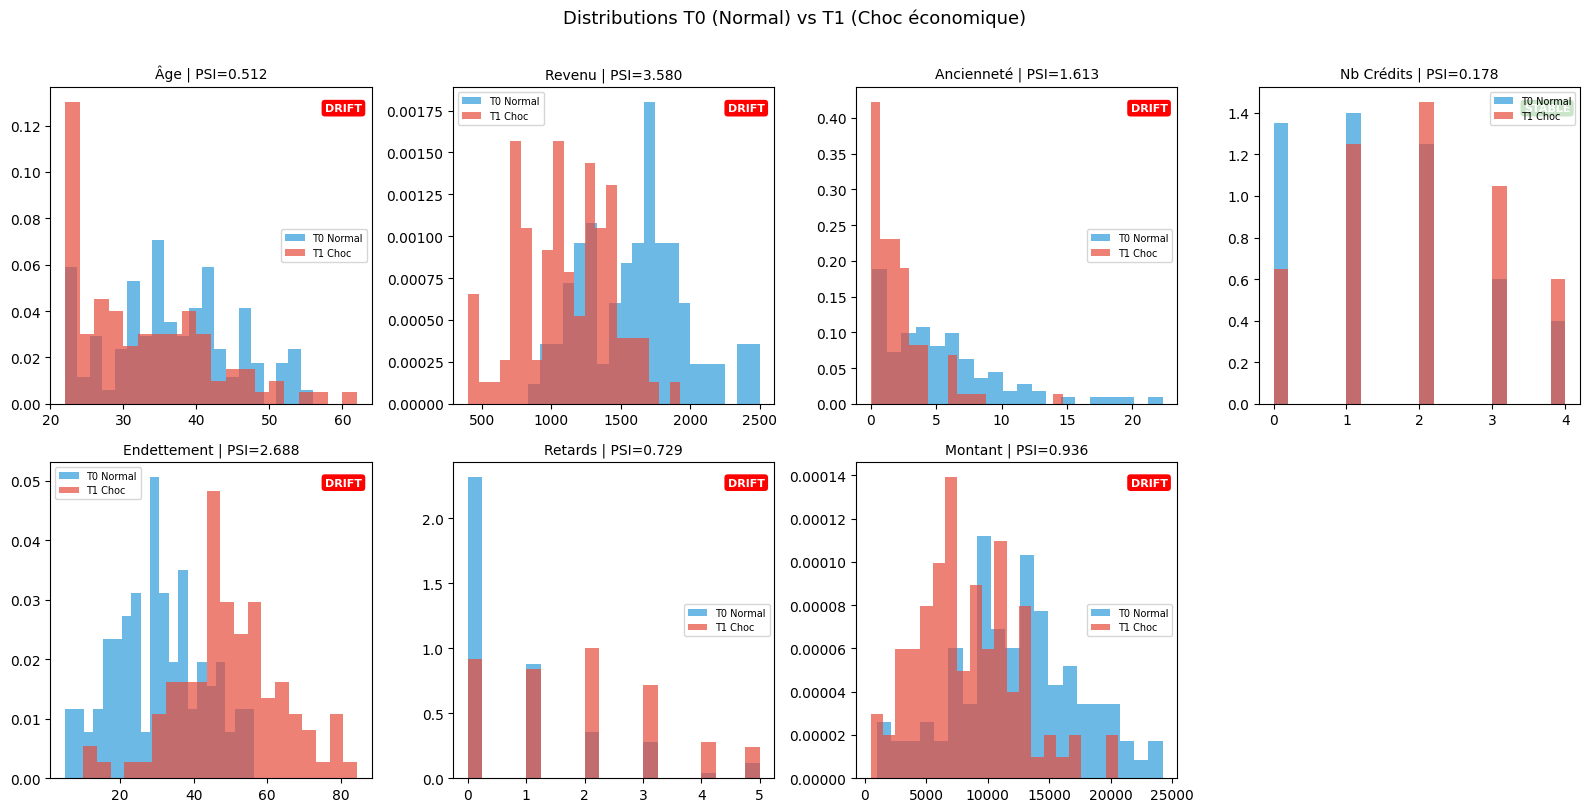

In [ ]:
LABELS = ["Âge", "Revenu", "Ancienneté", "Nb Crédits",
          "Endettement", "Retards", "Montant"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(FEATURES, LABELS)):
    ax = axes[i]

    ax.hist(df_normal[col], bins=20, alpha=0.7,
            color="#2E9CDB", density=True, label="T0 Normal")
    ax.hist(df_choc[col],   bins=20, alpha=0.7,
            color="#E74C3C", density=True, label="T1 Choc")

    psi  = calculer_psi(df_normal[col].values, df_choc[col].values)
    _, pval = stats.ks_2samp(df_normal[col], df_choc[col])

    badge = "DRIFT" if pval < 0.05 else "STABLE"
    color = "red" if pval < 0.05 else "green"

    ax.set_title(f"{label} | PSI={psi:.3f}", fontsize=10)
    ax.legend(fontsize=7)
    ax.text(0.97, 0.95, badge,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=8, fontweight="bold",
            color="white",
            bbox=dict(facecolor=color, edgecolor="none",
                      boxstyle="round,pad=0.3"))

axes[-1].set_visible(False)
plt.suptitle("Distributions T0 (Normal) vs T1 (Choc économique)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

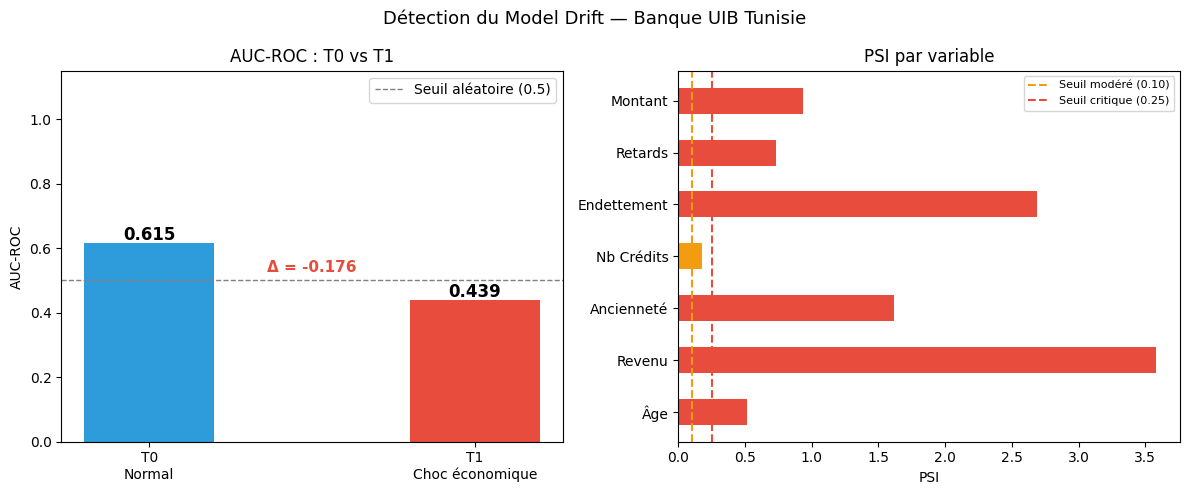

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Graphique 1 : AUC T0 vs T1 ──
ax1 = axes[0]
periodes = ["T0\nNormal", "T1\nChoc économique"]
aucs     = [auc_t0, auc_t1]
couleurs = ["#2E9CDB", "#E74C3C"]

bars = ax1.bar(periodes, aucs, color=couleurs, width=0.4, edgecolor="none")

for bar, val in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + 0.01, f"{val:.3f}",
             ha="center", fontsize=12,
             fontweight="bold")

ax1.axhline(0.5, color="gray", linestyle="--",
            linewidth=1, label="Seuil aléatoire (0.5)")
ax1.set_title("AUC-ROC : T0 vs T1", fontsize=12)
ax1.set_ylabel("AUC-ROC")
ax1.set_ylim(0, 1.15)
ax1.legend()

delta = auc_t1 - auc_t0
ax1.annotate(f"Δ = {delta:+.3f}",
             xy=(0.5, (auc_t0 + auc_t1)/2),
             ha="center", fontsize=11,
             color="#E74C3C", fontweight="bold")

# ── Graphique 2 : PSI par variable ──
ax2 = axes[1]
psi_vals = [calculer_psi(df_normal[c].values,
                         df_choc[c].values) for c in FEATURES]
couleurs_psi = ["#E74C3C" if v > 0.25
                else "#F39C12" if v > 0.10
                else "#2ECC71" for v in psi_vals]

ax2.barh(LABELS, psi_vals, color=couleurs_psi,
         height=0.5, edgecolor="none")
ax2.axvline(0.10, color="#F39C12", linestyle="--",
            linewidth=1.5, label="Seuil modéré (0.10)")
ax2.axvline(0.25, color="#E74C3C", linestyle="--",
            linewidth=1.5, label="Seuil critique (0.25)")
ax2.set_title("PSI par variable", fontsize=12)
ax2.set_xlabel("PSI")
ax2.legend(fontsize=8)

plt.suptitle("Détection du Model Drift — Banque UIB Tunisie",
             fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime

date = datetime.now().strftime("%d/%m/%Y à %H:%M")

rapport = f"""
╔══════════════════════════════════════════════════════════════╗
║         RAPPORT D'AUDIT — GOUVERNANCE DES MODÈLES IA        ║
║         Banque UIB Tunisie — Modèle Crédit Scoring          ║
╚══════════════════════════════════════════════════════════════╝

Date                    : {date}
Modèle                  : Random Forest
Données T0              : {len(df_normal)} clients (période normale)
Données T1              : {len(df_choc)} clients (choc économique)

══════════════════════════════════════════════════════════════
1. PERFORMANCES DU MODÈLE
══════════════════════════════════════════════════════════════

  AUC-ROC T0 (référence)   : {auc_t0:.4f}
  AUC-ROC T1 (production)  : {auc_t1:.4f}
  Variation                : {auc_t1-auc_t0:+.4f}

  Accuracy T0              : {acc_t0*100:.1f}%
  Accuracy T1              : {acc_t1*100:.1f}%

  Taux défaut T0           : {df_normal['Defaut'].mean()*100:.1f}%
  Taux défaut T1           : {df_choc['Defaut'].mean()*100:.1f}%

══════════════════════════════════════════════════════════════
2. DÉTECTION DU DRIFT (PSI)
══════════════════════════════════════════════════════════════

  {'Variable':<25} {'PSI':>8}   Statut
  {'─'*45}"""

for col, label in zip(FEATURES, LABELS):
    psi    = calculer_psi(df_normal[col].values, df_choc[col].values)
    statut = "CRITIQUE" if psi > 0.25 else "MODÉRÉ" if psi > 0.10 else "STABLE"
    rapport += f"\n  {label:<25} {psi:>8.4f}   {statut}"

rapport += f"""

══════════════════════════════════════════════════════════════
3. ALERTES
══════════════════════════════════════════════════════════════
"""

delta = auc_t1 - auc_t0
if delta < -0.10:
    rapport += f"  🔴 CRITIQUE : AUC a chuté de {abs(delta)*100:.1f} points\n"
    rapport += f"  → Ré-entraînement immédiat recommandé\n"
elif delta < -0.05:
    rapport += f"  🟠 ATTENTION : AUC a baissé de {abs(delta)*100:.1f} points\n"
    rapport += f"  → Surveiller dans les 30 jours\n"
else:
    rapport += f"  🟢 OK : Modèle stable\n"

nb_critique = sum(
    1 for col in FEATURES
    if calculer_psi(df_normal[col].values, df_choc[col].values) > 0.25
)
rapport += f"  Variables en drift critique : {nb_critique}/7\n"

rapport += f"""
══════════════════════════════════════════════════════════════
4. CONCLUSION
══════════════════════════════════════════════════════════════

  Le modèle de crédit scoring présente un drift significatif
  entre la période normale (T0) et le choc économique (T1).
  Une surveillance mensuelle est recommandée.

══════════════════════════════════════════════════════════════
  Rapport généré automatiquement — Système de Monitoring UIB
══════════════════════════════════════════════════════════════
"""

print(rapport)

with open("rapport_audit_UIB.txt", "w", encoding="utf-8") as f:
    f.write(rapport)

print("\n✅ Rapport sauvegardé → rapport_audit_UIB.txt")


╔══════════════════════════════════════════════════════════════╗
║         RAPPORT D'AUDIT — GOUVERNANCE DES MODÈLES IA        ║
║         Banque UIB Tunisie — Modèle Crédit Scoring          ║
╚══════════════════════════════════════════════════════════════╝

Date                    : 09/05/2026 à 10:08
Modèle                  : Random Forest
Données T0              : 100 clients (période normale)
Données T1              : 100 clients (choc économique)

══════════════════════════════════════════════════════════════
1. PERFORMANCES DU MODÈLE
══════════════════════════════════════════════════════════════

  AUC-ROC T0 (référence)   : 0.6154
  AUC-ROC T1 (production)  : 0.4389
  Variation                : -0.1765

  Accuracy T0              : 56.0%
  Accuracy T1              : 79.0%

  Taux défaut T0           : 52.0%
  Taux défaut T1           : 90.0%

══════════════════════════════════════════════════════════════
2. DÉTECTION DU DRIFT (PSI)
══════════════════════════════════════════════

In [ ]:
from ipywidgets import widgets
from IPython.display import display, clear_output

print("=" * 50)
print("   EVALUATION D'UN NOUVEAU CLIENT")
print("=" * 50)

# Widgets de saisie
age          = widgets.IntText(value=35,   description="Âge :")
revenu       = widgets.IntText(value=1800, description="Revenu DT :")
anciennete   = widgets.FloatText(value=5,  description="Ancienneté :")
nb_credits   = widgets.IntText(value=1,    description="Nb crédits :")
endettement  = widgets.FloatText(value=30, description="Endettement %:")
retards      = widgets.IntText(value=0,    description="Retards :")
montant      = widgets.IntText(value=10000,description="Montant DT :")
bouton       = widgets.Button(
    description="🔍 Évaluer le client",
    button_style="primary",
    layout=widgets.Layout(width="200px")
)
resultat = widgets.Output()

display(age, revenu, anciennete, nb_credits,
        endettement, retards, montant,
        bouton, resultat)

def evaluer(b):
    with resultat:
        clear_output()
        client = pd.DataFrame([[
            age.value, revenu.value, anciennete.value,
            nb_credits.value, endettement.value,
            retards.value, montant.value
        ]], columns=FEATURES)

        client_sc = scaler.transform(client)
        score     = modele.predict_proba(client_sc)[0][1]
        decision  = modele.predict(client_sc)[0]

        print("\n" + "─"*40)
        print(f"  Score de risque : {score:.4f}")
        print("─"*40)

        if score < 0.30:
            print("  ✅ CRÉDIT ACCORDÉ — Risque faible")
        elif score < 0.50:
            print("  🟠 ANALYSE REQUISE — Risque moyen")
        else:
            print("  ❌ CRÉDIT REFUSÉ — Risque élevé")
        print("─"*40)

bouton.on_click(evaluer)

   EVALUATION D'UN NOUVEAU CLIENT


IntText(value=35, description='Âge :')

IntText(value=1800, description='Revenu DT :')

FloatText(value=5.0, description='Ancienneté :')

IntText(value=1, description='Nb crédits :')

FloatText(value=30.0, description='Endettement %:')

IntText(value=0, description='Retards :')

IntText(value=10000, description='Montant DT :')

Button(button_style='primary', description='🔍 Évaluer le client', layout=Layout(width='200px'), style=ButtonSt…

Output()

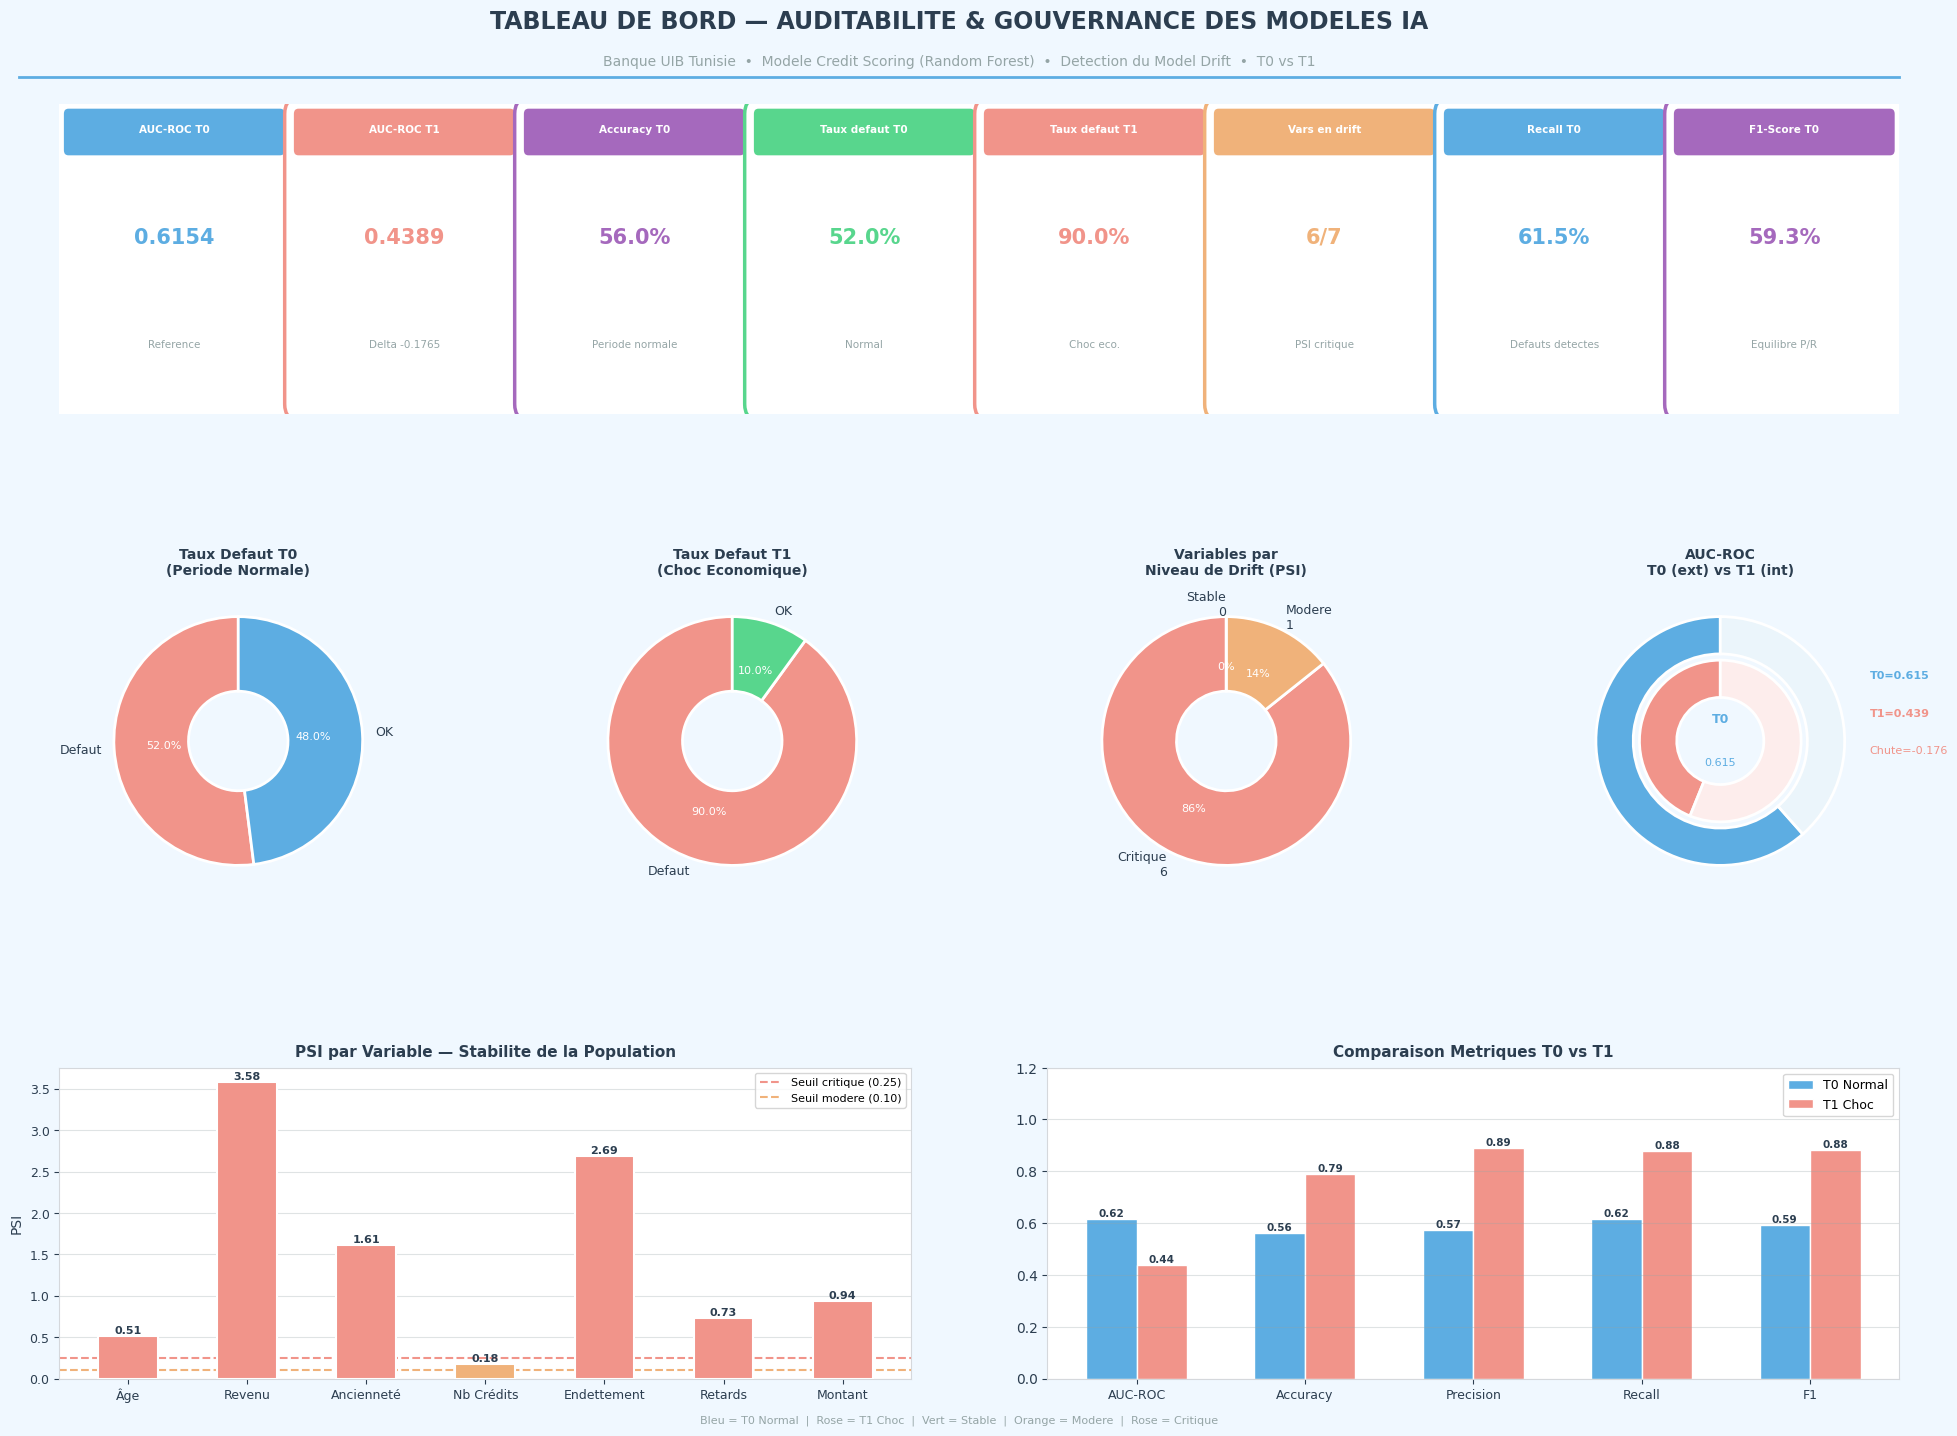

✅ Dashboard sauvegarde !


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np

# COULEURS CLAIRES
BG      = "#F0F8FF"   # fond bleu très clair
CARD    = "#FFFFFF"   # blanc
BLEU    = "#5DADE2"   # bleu ciel
ROSE    = "#F1948A"   # rose doux
VIOLET  = "#A569BD"   # violet clair
VERT    = "#58D68D"   # vert doux
ORANGE  = "#F0B27A"   # orange doux
MARRON  = "#2C3E50"   # texte foncé
GRIS    = "#95A5A6"   # texte gris

fig = plt.figure(figsize=(20, 15))
fig.patch.set_facecolor(BG)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.55, wspace=0.38,
                       top=0.90, bottom=0.05,
                       left=0.05, right=0.97)

# ── TITRE ──────────────────────────────────────
fig.text(0.5, 0.95,
    "TABLEAU DE BORD — AUDITABILITE & GOUVERNANCE DES MODELES IA",
    ha="center", fontsize=17, fontweight="bold", color=MARRON)
fig.text(0.5, 0.925,
    "Banque UIB Tunisie  •  Modele Credit Scoring (Random Forest)  •  Detection du Model Drift  •  T0 vs T1",
    ha="center", fontsize=10, color=GRIS)
fig.add_artist(plt.Line2D(
    [0.03, 0.97], [0.918, 0.918],
    transform=fig.transFigure,
    color=BLEU, linewidth=2))

# ── KPI CARDS ──────────────────────────────────
kpis = [
    ("AUC-ROC T0",      f"{auc_t0:.4f}",  BLEU,   f"Reference"),
    ("AUC-ROC T1",      f"{auc_t1:.4f}",  ROSE,   f"Delta {auc_t1-auc_t0:+.4f}"),
    ("Accuracy T0",     f"{acc_t0*100:.1f}%", VIOLET, "Periode normale"),
    ("Taux defaut T0",  f"{df_normal['Defaut'].mean()*100:.1f}%", VERT, "Normal"),
    ("Taux defaut T1",  f"{df_choc['Defaut'].mean()*100:.1f}%",  ROSE, "Choc eco."),
    ("Vars en drift",   f"{sum(1 for c in FEATURES if calculer_psi(df_normal[c].values, df_choc[c].values) > 0.25)}/7", ORANGE, "PSI critique"),
    ("Recall T0",       f"{recall*100:.1f}%",    BLEU,   "Defauts detectes"),
    ("F1-Score T0",     f"{f1*100:.1f}%",        VIOLET, "Equilibre P/R"),
]

ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor(BG)
ax_kpi.axis("off")
ax_kpi.set_xlim(0, 20)
ax_kpi.set_ylim(0, 3)

for i, (label, valeur, couleur, sous) in enumerate(kpis):
    x = i * 2.5 + 0.1
    rect = FancyBboxPatch(
        (x, 0.1), 2.3, 2.8,
        boxstyle="round,pad=0.15",
        facecolor=CARD,
        edgecolor=couleur,
        linewidth=2.5
    )
    ax_kpi.add_patch(rect)
    # Barre colorée en haut
    rect_top = FancyBboxPatch(
        (x, 2.55), 2.3, 0.35,
        boxstyle="round,pad=0.05",
        facecolor=couleur,
        edgecolor="none"
    )
    ax_kpi.add_patch(rect_top)
    ax_kpi.text(x+1.15, 2.72, label,
                ha="center", fontsize=7.5,
                color="white", fontweight="bold")
    ax_kpi.text(x+1.15, 1.65, valeur,
                ha="center", fontsize=15,
                color=couleur, fontweight="bold")
    ax_kpi.text(x+1.15, 0.65, sous,
                ha="center", fontsize=7.5,
                color=GRIS)

# ── PIE 1 : Taux défaut ────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor(CARD)
v1 = [df_normal['Defaut'].mean()*100,
      100 - df_normal['Defaut'].mean()*100]
wedges, texts, auto = ax1.pie(
    v1,
    labels=["Defaut", "OK"],
    colors=[ROSE, BLEU],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.6,
                    edgecolor="white",
                    linewidth=2)
)
for t in texts:
    t.set_fontsize(9); t.set_color(MARRON)
for a in auto:
    a.set_fontsize(8); a.set_color("white")
ax1.set_title("Taux Defaut T0\n(Periode Normale)",
              fontsize=10, fontweight="bold",
              color=MARRON, pad=8)

# ── PIE 2 : Taux défaut T1 ─────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(CARD)
v2 = [df_choc['Defaut'].mean()*100,
      100 - df_choc['Defaut'].mean()*100]
wedges2, texts2, auto2 = ax2.pie(
    v2,
    labels=["Defaut", "OK"],
    colors=[ROSE, VERT],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.6,
                    edgecolor="white",
                    linewidth=2)
)
for t in texts2:
    t.set_fontsize(9); t.set_color(MARRON)
for a in auto2:
    a.set_fontsize(8); a.set_color("white")
ax2.set_title("Taux Defaut T1\n(Choc Economique)",
              fontsize=10, fontweight="bold",
              color=MARRON, pad=8)

# ── PIE 3 : Variables drift ────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor(CARD)
nb_c = sum(1 for c in FEATURES if calculer_psi(
    df_normal[c].values, df_choc[c].values) > 0.25)
nb_m = sum(1 for c in FEATURES if 0.10 < calculer_psi(
    df_normal[c].values, df_choc[c].values) <= 0.25)
nb_s = len(FEATURES) - nb_c - nb_m
wedges3, texts3, auto3 = ax3.pie(
    [nb_c, nb_m, nb_s],
    labels=[f"Critique\n{nb_c}",
            f"Modere\n{nb_m}",
            f"Stable\n{nb_s}"],
    colors=[ROSE, ORANGE, VERT],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops=dict(width=0.6,
                    edgecolor="white",
                    linewidth=2)
)
for t in texts3:
    t.set_fontsize(9); t.set_color(MARRON)
for a in auto3:
    a.set_fontsize(8); a.set_color("white")
ax3.set_title("Variables par\nNiveau de Drift (PSI)",
              fontsize=10, fontweight="bold",
              color=MARRON, pad=8)

# ── DONUT : AUC T0 vs T1 ──────────────────────
ax4 = fig.add_subplot(gs[1, 3])
ax4.set_facecolor(CARD)
ax4.pie([auc_t0, 1-auc_t0],
        colors=[BLEU, "#EBF5FB"],
        startangle=90, radius=1.0,
        wedgeprops=dict(width=0.3,
                        edgecolor="white",
                        linewidth=2))
ax4.pie([auc_t1, 1-auc_t1],
        colors=[ROSE, "#FDEDEC"],
        startangle=90, radius=0.65,
        wedgeprops=dict(width=0.3,
                        edgecolor="white",
                        linewidth=2))
ax4.text(0, 0.15, f"T0",
         ha="center", fontsize=9,
         color=BLEU, fontweight="bold")
ax4.text(0, -0.2, f"{auc_t0:.3f}",
         ha="center", fontsize=8, color=BLEU)
ax4.text(1.2, 0.5, f"T0={auc_t0:.3f}",
         fontsize=8, color=BLEU, fontweight="bold")
ax4.text(1.2, 0.2, f"T1={auc_t1:.3f}",
         fontsize=8, color=ROSE, fontweight="bold")
ax4.text(1.2, -0.1, f"Chute={auc_t1-auc_t0:+.3f}",
         fontsize=8, color=ROSE)
ax4.set_title("AUC-ROC\nT0 (ext) vs T1 (int)",
              fontsize=10, fontweight="bold",
              color=MARRON, pad=8)

# ── BARRES : PSI par variable ──────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.set_facecolor(CARD)
psi_vals = [calculer_psi(df_normal[c].values,
                         df_choc[c].values) for c in FEATURES]
cols_psi = [ROSE if v > 0.25
            else ORANGE if v > 0.10
            else VERT for v in psi_vals]
bars5 = ax5.bar(LABELS, psi_vals,
                color=cols_psi, width=0.5,
                edgecolor="white",
                linewidth=1.5, zorder=3)
for bar, val in zip(bars5, psi_vals):
    ax5.text(bar.get_x() + bar.get_width()/2,
             val + 0.03, f"{val:.2f}",
             ha="center", fontsize=8,
             fontweight="bold", color=MARRON)
ax5.axhline(0.25, color=ROSE,
            linestyle="--", lw=1.5,
            label="Seuil critique (0.25)")
ax5.axhline(0.10, color=ORANGE,
            linestyle="--", lw=1.5,
            label="Seuil modere (0.10)")
ax5.set_title("PSI par Variable — Stabilite de la Population",
              fontsize=11, fontweight="bold",
              color=MARRON, pad=8)
ax5.set_ylabel("PSI", color=MARRON)
ax5.tick_params(colors=MARRON, labelsize=9)
ax5.legend(fontsize=8)
ax5.grid(axis="y", alpha=0.3, color=GRIS)
for sp in ax5.spines.values():
    sp.set_color("#D5D8DC")

# ── BARRES : Métriques T0 vs T1 ───────────────
ax6 = fig.add_subplot(gs[2, 2:])
ax6.set_facecolor(CARD)
noms = ["AUC-ROC", "Accuracy",
        "Precision", "Recall", "F1"]
v_t0 = [auc_t0, acc_t0,
        precision, recall, f1]
v_t1 = [auc_t1, acc_t1,
        precision_t1, recall_t1, f1_t1]

x     = np.arange(len(noms))
width = 0.3
b1 = ax6.bar(x - width/2, v_t0, width,
             color=BLEU, label="T0 Normal",
             edgecolor="white")
b2 = ax6.bar(x + width/2, v_t1, width,
             color=ROSE, label="T1 Choc",
             edgecolor="white")

for bar in list(b1) + list(b2):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.2f}",
             ha="center", fontsize=7.5,
             color=MARRON, fontweight="bold")

ax6.set_title("Comparaison Metriques T0 vs T1",
              fontsize=11, fontweight="bold",
              color=MARRON, pad=8)
ax6.set_xticks(x)
ax6.set_xticklabels(noms, color=MARRON,
                    fontsize=9)
ax6.set_ylim(0, 1.2)
ax6.tick_params(colors=MARRON)
ax6.legend(fontsize=9)
ax6.grid(axis="y", alpha=0.3, color=GRIS)
for sp in ax6.spines.values():
    sp.set_color("#D5D8DC")

# PIED DE PAGE
fig.text(0.5, 0.02,
    "Bleu = T0 Normal  |  Rose = T1 Choc  |  Vert = Stable  |  Orange = Modere  |  Rose = Critique",
    ha="center", fontsize=8, color=GRIS)

plt.savefig("dashboard_UIB.png", dpi=150,
            bbox_inches="tight",
            facecolor=BG)
plt.show()
print("✅ Dashboard sauvegarde !")